# Visualizing categorical data

In the [relational plot tutorial](./05_relplot.ipynb) we saw how to use different visual representations to show the relationship between multiple variables in a dataset. In the examples, we focused on cases where the main relationship was between two numerical variables. **If one of the main variables is “categorical” (divided into discrete groups) it may be helpful to use a more specialized approach to visualization**.

![](../assets/catplot.png)

It’s helpful to think of the different categorical plot kinds as belonging to **three different families**, which we’ll discuss in detail below. They are:

1. **Categorical scatterplots**:
   - [`stripplot()`](https://seaborn.pydata.org/generated/seaborn.stripplot.html#seaborn.stripplot) (with `kind="strip"`; the default)
   - [`swarmplot()`](https://seaborn.pydata.org/generated/seaborn.swarmplot.html#seaborn.swarmplot) (with `kind="swarm"`)
2. **Categorical distribution plots**:
   - [`boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot) (with `kind="box"`)
   - [`boxenplot()`](https://seaborn.pydata.org/generated/seaborn.boxenplot.html#seaborn.boxenplot) (with `kind="boxen"`)
   - [`violinplot()`](https://seaborn.pydata.org/generated/seaborn.violinplot.html#seaborn.violinplot) (with `kind="violin"`)
3. **Categorical estimate plots**:
   - [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn.countplot) (with `kind="count"`)
   - [`barplot()`](https://seaborn.pydata.org/generated/seaborn.barplot.html#seaborn.barplot) (with `kind="bar"`)
   - [`pointplot()`](https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot) (with `kind="point"`)

The unified API [`catplot()`](https://seaborn.pydata.org/generated/seaborn.catplot.html#seaborn.catplot) makes it easy to switch between different kinds and see your data from several perspectives.

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
tips = sns.load_dataset("tips")
tips.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


## Categorical scatterplots: Stripplot vs Swarmplot

Scatterplots may have overlap, hence we may solve it by reducing transparency (`alpha=0.6`) or using **Swarm Plot** instead of the default **Strip Plot**:

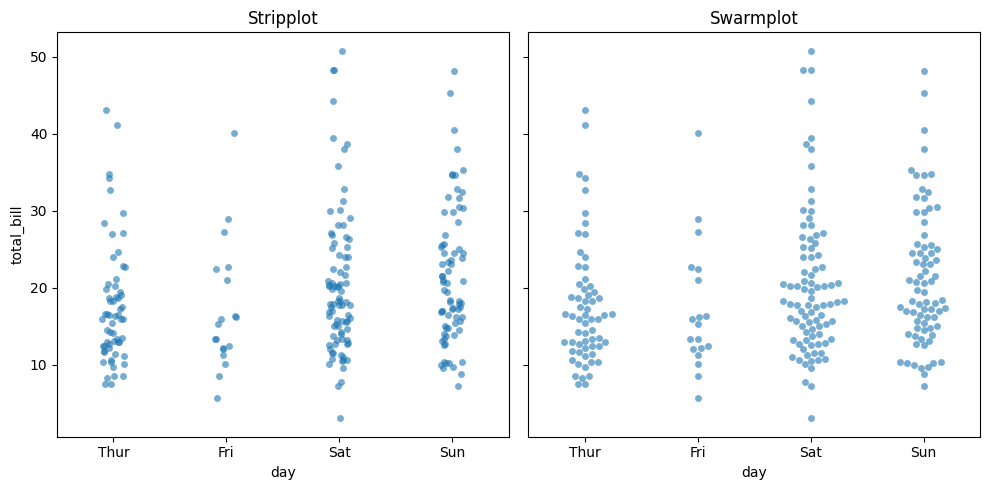

In [4]:
# Stripplot and swarmplot are axes-level functions, so use them directly (not catplot) for subplotting
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(10, 5),
    sharey=True
)

sns.stripplot(data=tips, x="day", y="total_bill", ax=axes[0], alpha=0.6)
axes[0].set_title("Stripplot")

sns.swarmplot(data=tips, x="day", y="total_bill", ax=axes[1], alpha=0.6)
axes[1].set_title("Swarmplot")

plt.tight_layout()
plt.show()

### Conditional on a third variable (using `hue`)

Similar to the relational plots, it’s possible to add another dimension to a categorical plot by using a `hue` semantic. (The categorical plots **do not** currently support `size` or `style` semantics). Each different categorical plotting function handles the `hue` semantic differently. For the scatter plots, it is only necessary to change the color of the points:

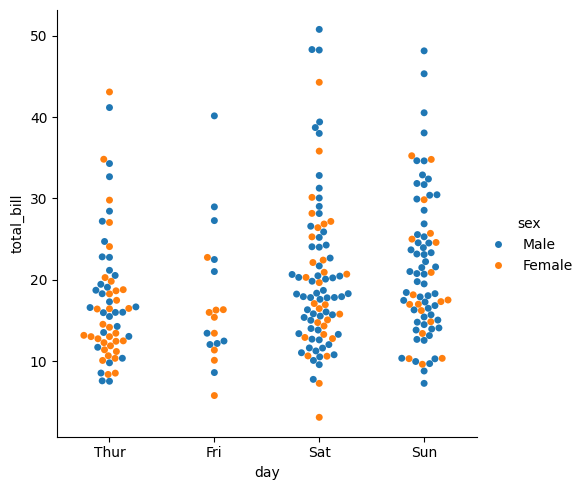

In [5]:
sns.catplot(
    data=tips,
    kind="swarm",
    x="day",
    y="total_bill",
    hue="sex",
)

### Control Order

The **ordering can also be controlled** on a plot-specific basis using the order parameter. This can be important when drawing multiple categorical plots in the same figure, which we’ll see more of below:

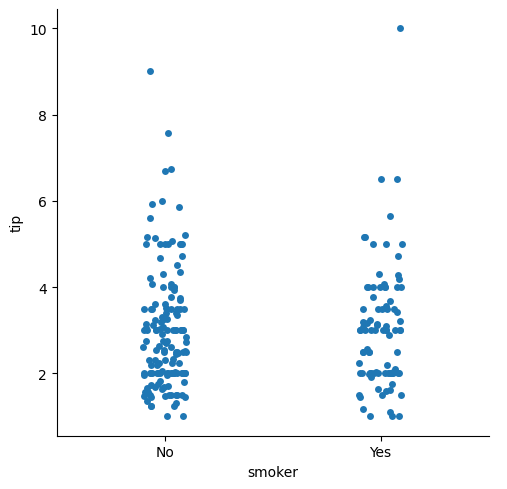

In [6]:
sns.catplot(
    data=tips,
    kind="strip",
    x="smoker",
    y="tip",
    order=["No", "Yes"],
)

### Horirzontally

it’s often helpful to put the categorical variable **on the vertical axis** instead, specifically, when:

1. the category **names are relatively long**
2. or **there are many categories**

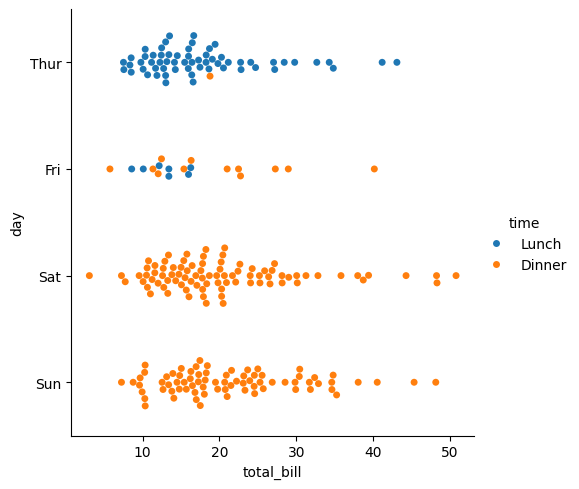

In [7]:
sns.catplot(
    data=tips,
    kind="swarm",
    x="total_bill",
    y="day",
    hue="time",
)

## Comparing distributions

**As the size of the dataset grows**, categorical scatter plots become limited in the information they can provide about the distribution of values within each category. When this happens, there are several approaches for summarizing the distributional information in ways that facilitate easy comparisons across the category levels.

### Boxplots

The first is the familiar [`boxplot()`](https://seaborn.pydata.org/generated/seaborn.boxplot.html#seaborn.boxplot "seaborn.boxplot"). This kind of plot shows the three quartile values of the distribution along with extreme values. The “whiskers” extend to points that lie within 1.5 IQRs of the lower and upper quartile, and then observations that fall outside this range are displayed independently. This means that each value in the boxplot corresponds to an actual observation in the data.

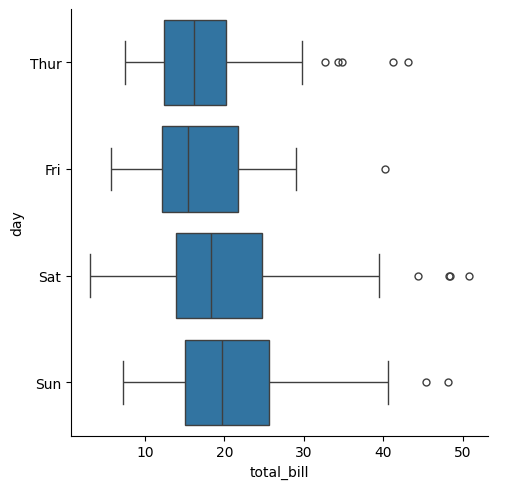

In [ ]:
sns.catplot(
    data=tips,
    kind="box",
    y="day",
    x="total_bill",
)

For further customization of the plot, you can use the methods on the **FacetGrid** object that it returns. Let's demonstrate using the `titantic` dataset:

In [9]:
titanic = sns.load_dataset("titanic")
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


Calling `sns.catplot()` returns a **FacetGrid**, `g`, whoose `g.axes` are accessible:

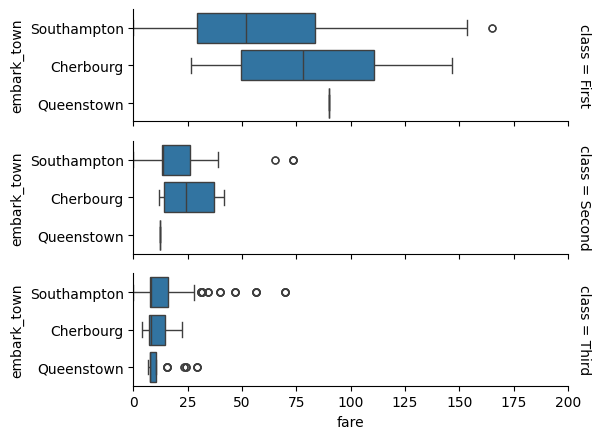

In [23]:
g = sns.catplot(
    data=titanic,
    kind="box",
    x="fare",
    y="embark_town",
    row="class",          # split the data into three plots
    orient="h",           # horizontal orientation
    sharex=True,          # x-axis is different for all three plots
    margin_titles=True,   # add a title to each facet
    height=1.5, aspect=4, # set the size of the figure
)

for ax in g.axes.flat:
    ax.set_xlim(0, 200)

Notice the x-axis is the same for all three plots since we specified `sharex=True`.

## Count Plot

In seaborn, the [`countplot()`](https://seaborn.pydata.org/generated/seaborn.countplot.html#seaborn.countplot) function is **similar to a histogram over a categorical, rather than quantitative, variable**. Notice that we neve specify the y-axis, because it is implicitly the `count`:

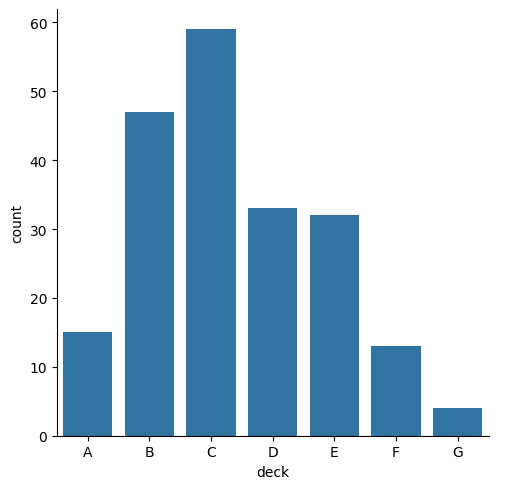

In [24]:
sns.catplot(data=titanic, kind="count", x="deck")

## Estimating central tendency

For other applications, rather than showing the distribution within each category, you might want to show **an estimate of the central tendency of the values**.

### Point plots

An alternative style for visualizing the same information is offered by the [`pointplot()`](https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot "seaborn.pointplot") function. This function:

1. also encodes the value of the estimate with height on the other axis, **but rather than showing a full bar, it plots the point estimate and confidence interval**.
2. Additionally, [`pointplot()`](https://seaborn.pydata.org/generated/seaborn.pointplot.html#seaborn.pointplot "seaborn.pointplot") connects points from the same `hue` category. This makes it easy to see how the main relationship is changing as a function of the hue semantic, **because your eyes are quite good at picking up on differences of slopes**
3. It can still be a good idea to vary the `marker` and/or linestyle along with the `hue` to make figures that are maximally accessible and reproduce well in black and white:

In [31]:
import pandas as pd

wpm = pd.read_csv('../../data/wpm.csv')
print(wpm[:3])
print(wpm[-3:])

   wpm  light
0   11  False
1   15  False
2   50  False
    wpm  light
23   42   True
24   36   True
25   40   True


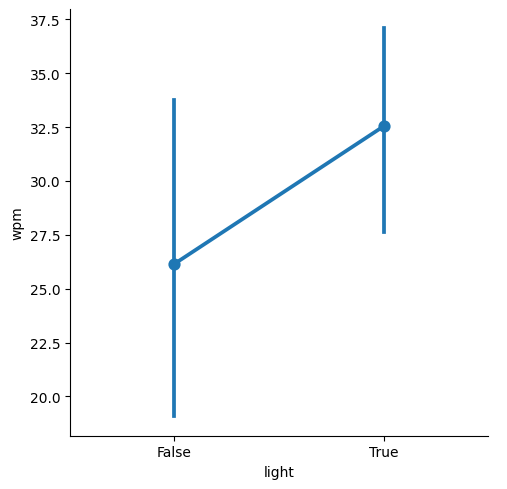

In [33]:
sns.catplot(
    data=wpm, x="light", y="wpm",
    kind="point",
)